In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
column_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
    "AGE", "DIS", "RAD", "TAX", "PTRATIO",
    "B", "LSTAT", "MEDV"
]

df = pd.read_csv(
    "../datasets/house Prediction Data Set.csv",
    header=None,
    names=column_names,
    sep=r"\s+"
)

df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:

X = df.drop("MEDV", axis=1)

y = df["MEDV"]

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [7]:
predictions = model.predict(X_test)

In [8]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.2f}")

MAE  : 3.19
MSE  : 24.29
RMSE : 4.93
R² Score : 0.67


In [9]:

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

results.head(10)

,Actual Price,Predicted Price
173,23.6,28.996724
274,32.4,36.025565
491,13.6,14.816944
72,22.8,25.031979
452,16.1,18.769880
76,20.0,23.254429
316,17.8,17.662538
140,14.0,14.341190
471,19.6,23.013207
500,16.8,20.632456


In [10]:

results.to_csv("predictions.csv", index=False)

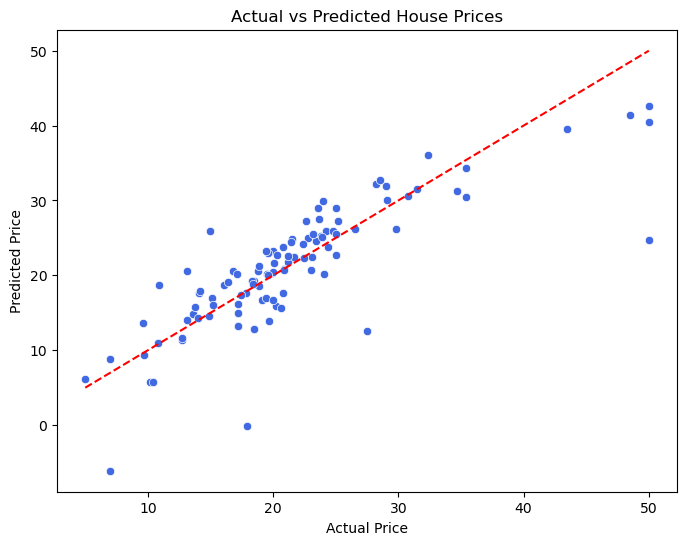

In [11]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=predictions,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.savefig("../images/Actual_vs_Predicted.png",
            dpi=300,
            bbox_inches="tight")

plt.show()


In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coefficients

,Feature,Coefficient
4,NOX,-17.202633
5,RM,4.438835
3,CHAS,2.784438
7,DIS,-1.447865
10,PTRATIO,-0.915456
12,LSTAT,-0.508571
8,RAD,0.262430
0,CRIM,-0.113056
2,INDUS,0.040381
1,ZN,0.030110


In [14]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']